Questo file aiuta a comparare due dataset che hanno stesse variabili.\
Obbiettivo fare analisi per verificare che i metodi utilizzati per ottenere i dati siano equivalenti.

# IMPORT

In [19]:
from dl_client import DatalakeClient
import pandas as pd

client = DatalakeClient()

# Funzioni statistiche

In [20]:
## FUNZIONI PER I TEST STATISTICI

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import t
import warnings
warnings.filterwarnings('ignore')

# Installa questi pacchetti se non li hai:
#

import pingouin as pg
import statsmodels.api as sm
from statsmodels.stats.inter_rater import aggregate_raters

# ========================================
# FUNZIONI PER I TEST STATISTICI
# ========================================

def paired_t_test(x, y, alpha=0.05):
    """
    Esegue paired t-test
    """
    # Calcola le differenze
    differences = x - y
    n = len(differences)
    
    # Statistiche descrittive
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)
    se_diff = std_diff / np.sqrt(n)
    
    # T-test
    t_stat, p_value = stats.ttest_rel(x, y)
    
    # Intervallo di confidenza al 95%
    ci_low = mean_diff - t.ppf(1-alpha/2, n-1) * se_diff
    ci_high = mean_diff + t.ppf(1-alpha/2, n-1) * se_diff
    
    # Effect size (Cohen's d)
    cohens_d = mean_diff / std_diff
    
    results = {
        'test': 'Paired t-test',
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        't_statistic': t_stat,
        'p_value': p_value,
        'ci_95': (ci_low, ci_high),
        'cohens_d': cohens_d,
        'n': n,
        'significant': p_value < alpha
    }
    
    return results

def wilcoxon_test(x, y, alpha=0.05):
    """
    Esegue Wilcoxon signed-rank test
    """
    # Test di Wilcoxon
    statistic, p_value = stats.wilcoxon(x, y, alternative='two-sided')
    
    # Calcola pseudo-mediana (Hodges-Lehmann estimator)
    differences = x - y
    walsh_averages = []
    for i in range(len(differences)):
        for j in range(i, len(differences)):
            walsh_averages.append((differences[i] + differences[j]) / 2)
    pseudo_median = np.median(walsh_averages)
    
    # Effect size per Wilcoxon (r = Z / sqrt(N))
    n = len(differences)
    z_score = stats.norm.ppf(1 - p_value/2)  # Approssimazione
    effect_size_r = z_score / np.sqrt(n)
    
    results = {
        'test': 'Wilcoxon signed-rank test',
        'statistic': statistic,
        'p_value': p_value,
        'pseudo_median': pseudo_median,
        'median_diff': np.median(differences),
        'effect_size_r': effect_size_r,
        'n': n,
        'significant': p_value < alpha
    }
    
    return results

def bland_altman_analysis(x, y, confidence=0.95):
    """
    Analisi di Bland-Altman
    """
    # Calcola medie e differenze
    mean_values = (x + y) / 2
    differences = x - y
    
    # Statistiche
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)
    n = len(differences)
    
    # Limiti di accordo (LoA)
    z_score = stats.norm.ppf(1 - (1 - confidence) / 2)
    loa_lower = mean_diff - z_score * std_diff
    loa_upper = mean_diff + z_score * std_diff
    
    # Intervalli di confidenza per bias e LoA
    se_mean = std_diff / np.sqrt(n)
    se_loa = np.sqrt(3 * std_diff**2 / n)
    
    ci_mean = (mean_diff - z_score * se_mean, 
               mean_diff + z_score * se_mean)
    ci_lower = (loa_lower - z_score * se_loa,
                loa_lower + z_score * se_loa)
    ci_upper = (loa_upper - z_score * se_loa,
                loa_upper + z_score * se_loa)
    
    # Test per bias sistematico (t-test su media delle differenze)
    t_stat = mean_diff / se_mean
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n-1))
    
    # Coefficiente di ripetibilità
    repeatability_coeff = 1.96 * std_diff
    
    # Percentage error
    mean_all = np.mean(np.concatenate([x, y]))
    percentage_error = (std_diff / mean_all) * 100 if mean_all != 0 else np.nan
    
    results = {
        'test': 'Bland-Altman Analysis',
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        'loa_lower': loa_lower,
        'loa_upper': loa_upper,
        'ci_mean': ci_mean,
        'ci_loa_lower': ci_lower,
        'ci_loa_upper': ci_upper,
        'bias_test_p': p_value,
        'repeatability_coeff': repeatability_coeff,
        'percentage_error': percentage_error,
        'n': n
    }
    
    return results, mean_values, differences

def concordance_correlation_coefficient(x, y):
    """
    Calcola il Concordance Correlation Coefficient (CCC) di Lin
    """
    # Medie
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    # Varianze
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    
    # Deviazioni standard
    std_x = np.sqrt(var_x)
    std_y = np.sqrt(var_y)
    
    # Covarianza
    covariance = np.cov(x, y)[0, 1]
    
    # Correlazione di Pearson
    pearson_r = covariance / (std_x * std_y)
    
    # CCC
    ccc = (2 * covariance) / (var_x + var_y + (mean_x - mean_y)**2)
    
    # Componenti del CCC
    # Precision (correlazione di Pearson)
    precision = pearson_r
    
    # Accuracy (Cb - bias correction factor)
    accuracy = ccc / pearson_r if pearson_r != 0 else 0
    
    # Bootstrap per intervallo di confidenza
    n_bootstrap = 1000
    ccc_bootstrap = []
    n = len(x)
    
    for _ in range(n_bootstrap):
        indices = np.random.choice(n, n, replace=True)
        x_boot = x[indices]
        y_boot = y[indices]
        
        mean_x_boot = np.mean(x_boot)
        mean_y_boot = np.mean(y_boot)
        var_x_boot = np.var(x_boot, ddof=1)
        var_y_boot = np.var(y_boot, ddof=1)
        cov_boot = np.cov(x_boot, y_boot)[0, 1]
        
        ccc_boot = (2 * cov_boot) / (var_x_boot + var_y_boot + 
                                     (mean_x_boot - mean_y_boot)**2)
        ccc_bootstrap.append(ccc_boot)
    
    ci_lower = np.percentile(ccc_bootstrap, 2.5)
    ci_upper = np.percentile(ccc_bootstrap, 97.5)
    
    # Interpretazione
    if ccc > 0.99:
        strength = "Quasi perfetto"
    elif ccc > 0.95:
        strength = "Sostanziale"
    elif ccc > 0.90:
        strength = "Moderato"
    elif ccc > 0.80:
        strength = "Scarso"
    else:
        strength = "Molto scarso"
    
    results = {
        'test': 'Concordance Correlation Coefficient',
        'ccc': ccc,
        'pearson_r': pearson_r,
        'precision': precision,
        'accuracy': accuracy,
        'ci_95': (ci_lower, ci_upper),
        'interpretation': strength,
        'n': n
    }
    
    return results

def intraclass_correlation(x, y):
    """
    Calcola Intraclass Correlation Coefficient (ICC)
    Usa ICC(2,1) - appropriato per due metodi fissi, stessi soggetti
    """
    # Prepara i dati in formato lungo
    n = len(x)
    data_long = pd.DataFrame({
        'subject': list(range(n)) * 2,
        'method': ['Method1'] * n + ['Method2'] * n,
        'value': np.concatenate([x, y])
    })
    
    # Calcola ICC usando pingouin
    icc_result = pg.intraclass_corr(data=data_long, 
                                    targets='subject',
                                    raters='method',
                                    ratings='value')
    
    # Estrai ICC(2,1) - per accordo assoluto
    icc_21 = icc_result[icc_result['Type'] == 'ICC2']['ICC'].values[0]
    ci_lower = icc_result[icc_result['Type'] == 'ICC2']['CI95%'].values[0][0]
    ci_upper = icc_result[icc_result['Type'] == 'ICC2']['CI95%'].values[0][1]
    
    # Calcola anche ICC(2,k) per affidabilità media
    icc_2k = icc_result[icc_result['Type'] == 'ICC2k']['ICC'].values[0]
    
    # Interpretazione (Koo & Li, 2016)
    if icc_21 < 0.5:
        reliability = "Scarsa"
    elif icc_21 < 0.75:
        reliability = "Moderata"
    elif icc_21 < 0.90:
        reliability = "Buona"
    else:
        reliability = "Eccellente"
    
    # Calcola anche componenti della varianza
    # Between-subject variance
    grand_mean = np.mean(data_long['value'])
    subject_means = data_long.groupby('subject')['value'].mean()
    var_between = np.var(subject_means, ddof=1) * 2  # moltiplicato per k=2 metodi
    
    # Within-subject variance
    var_within = np.mean([np.var([x[i], y[i]], ddof=1) for i in range(n)])
    
    results = {
        'test': 'Intraclass Correlation Coefficient',
        'icc_21': icc_21,
        'icc_2k': icc_2k,
        'ci_95': (ci_lower, ci_upper),
        'interpretation': reliability,
        'var_between': var_between,
        'var_within': var_within,
        'n': n
    }
    
    return results, icc_result

# ========================================
# FUNZIONE PRINCIPALE DI ANALISI
# ========================================

def comprehensive_method_comparison(x, y, method1_name="Metodo 1", 
                                   method2_name="Metodo 2",
                                   alpha=0.05, create_plots=True):
    """
    Esegue tutti i test di confronto tra due metodi
    
    Parameters:
    -----------
    x, y : array-like
        Misurazioni dai due metodi
    method1_name, method2_name : str
        Nomi dei metodi per le etichette
    alpha : float
        Livello di significatività
    create_plots : bool
        Se True, crea i grafici
    """
    
    # Converti in array numpy
    x = np.array(x)
    y = np.array(y)
    
    # Verifica che abbiano la stessa lunghezza
    assert len(x) == len(y), "x e y devono avere la stessa lunghezza"
    
    print("="*80)
    print("ANALISI COMPLETA DI CONFRONTO TRA METODI")
    print("="*80)
    print(f"Metodo 1: {method1_name}")
    print(f"Metodo 2: {method2_name}")
    print(f"Numero di osservazioni: {len(x)}")
    print("="*80)
    
    # ========================================
    # 1. STATISTICHE DESCRITTIVE
    # ========================================
    print("\n1. STATISTICHE DESCRITTIVE")
    print("-"*50)
    
    desc_stats = pd.DataFrame({
        method1_name: [np.mean(x), np.median(x), np.std(x, ddof=1), 
                       np.min(x), np.max(x), stats.skew(x), stats.kurtosis(x)],
        method2_name: [np.mean(y), np.median(y), np.std(y, ddof=1),
                       np.min(y), np.max(y), stats.skew(y), stats.kurtosis(y)],
        'Differenza': [np.mean(x-y), np.median(x-y), np.std(x-y, ddof=1),
                       np.min(x-y), np.max(x-y), stats.skew(x-y), stats.kurtosis(x-y)]
    }, index=['Media', 'Mediana', 'Dev. Std', 'Min', 'Max', 'Asimmetria', 'Curtosi'])
    
    print(desc_stats.round(4))
    
    # ========================================
    # 2. TEST DI NORMALITÀ
    # ========================================
    print("\n2. TEST DI NORMALITÀ DELLE DIFFERENZE")
    print("-"*50)
    
    differences = x - y
    
    # Shapiro-Wilk test
    if len(differences) <= 5000:
        shapiro_stat, shapiro_p = stats.shapiro(differences)
        print(f"Test di Shapiro-Wilk: W={shapiro_stat:.6f}, p={shapiro_p:.6f}")
        normal_assumption = shapiro_p > alpha
    else:
        print("Dataset troppo grande per Shapiro-Wilk, uso Kolmogorov-Smirnov")
        ks_stat, ks_p = stats.kstest((differences - np.mean(differences))/np.std(differences, ddof=1), 'norm')
        print(f"Test di Kolmogorov-Smirnov: D={ks_stat:.6f}, p={ks_p:.6f}")
        normal_assumption = ks_p > alpha
    
    print(f"→ Distribuzione normale: {'SÌ' if normal_assumption else 'NO'} (α={alpha})")
    
    # ========================================
    # 3. PAIRED T-TEST
    # ========================================
    print("\n3. PAIRED T-TEST")
    print("-"*50)
    
    t_results = paired_t_test(x, y, alpha)
    print(f"Differenza media: {t_results['mean_diff']:.4f} ± {t_results['std_diff']:.4f}")
    print(f"IC 95%: [{t_results['ci_95'][0]:.4f}, {t_results['ci_95'][1]:.4f}]")
    print(f"t-statistic: {t_results['t_statistic']:.4f}")
    print(f"p-value: {t_results['p_value']:.6f}")
    print(f"Cohen's d: {t_results['cohens_d']:.4f}")
    print(f"→ Differenza significativa: {'SÌ' if t_results['significant'] else 'NO'} (α={alpha})")
    
    # ========================================
    # 4. WILCOXON SIGNED-RANK TEST
    # ========================================
    print("\n4. WILCOXON SIGNED-RANK TEST")
    print("-"*50)
    
    wilcox_results = wilcoxon_test(x, y, alpha)
    print(f"Mediana delle differenze: {wilcox_results['median_diff']:.4f}")
    print(f"Pseudo-mediana (Hodges-Lehmann): {wilcox_results['pseudo_median']:.4f}")
    print(f"Statistica W: {wilcox_results['statistic']:.4f}")
    print(f"p-value: {wilcox_results['p_value']:.6f}")
    print(f"Effect size r: {wilcox_results['effect_size_r']:.4f}")
    print(f"→ Differenza significativa: {'SÌ' if wilcox_results['significant'] else 'NO'} (α={alpha})")
    
    # ========================================
    # 5. BLAND-ALTMAN ANALYSIS
    # ========================================
    print("\n5. BLAND-ALTMAN ANALYSIS")
    print("-"*50)
    
    ba_results, ba_means, ba_diffs = bland_altman_analysis(x, y)
    print(f"Bias (differenza media): {ba_results['mean_diff']:.4f}")
    print(f"IC 95% del bias: [{ba_results['ci_mean'][0]:.4f}, {ba_results['ci_mean'][1]:.4f}]")
    print(f"Dev. Std. delle differenze: {ba_results['std_diff']:.4f}")
    print(f"Limiti di accordo al 95%:")
    print(f"  Inferiore: {ba_results['loa_lower']:.4f} [{ba_results['ci_loa_lower'][0]:.4f}, {ba_results['ci_loa_lower'][1]:.4f}]")
    print(f"  Superiore: {ba_results['loa_upper']:.4f} [{ba_results['ci_loa_upper'][0]:.4f}, {ba_results['ci_loa_upper'][1]:.4f}]")
    print(f"Coefficiente di ripetibilità: {ba_results['repeatability_coeff']:.4f}")
    print(f"Errore percentuale: {ba_results['percentage_error']:.2f}%")
    print(f"Test per bias sistematico: p={ba_results['bias_test_p']:.6f}")
    
    # ========================================
    # 6. CONCORDANCE CORRELATION COEFFICIENT
    # ========================================
    print("\n6. CONCORDANCE CORRELATION COEFFICIENT (LIN)")
    print("-"*50)
    
    ccc_results = concordance_correlation_coefficient(x, y)
    print(f"CCC: {ccc_results['ccc']:.4f}")
    print(f"IC 95%: [{ccc_results['ci_95'][0]:.4f}, {ccc_results['ci_95'][1]:.4f}]")
    print(f"Correlazione di Pearson: {ccc_results['pearson_r']:.4f}")
    print(f"Precisione: {ccc_results['precision']:.4f}")
    print(f"Accuratezza: {ccc_results['accuracy']:.4f}")
    print(f"→ Interpretazione: {ccc_results['interpretation']}")
    
    # ========================================
    # 7. INTRACLASS CORRELATION COEFFICIENT
    # ========================================
    print("\n7. INTRACLASS CORRELATION COEFFICIENT")
    print("-"*50)
    
    icc_results, icc_full = intraclass_correlation(x, y)
    print(f"ICC(2,1) - Accordo assoluto: {icc_results['icc_21']:.4f}")
    print(f"IC 95%: [{icc_results['ci_95'][0]:.4f}, {icc_results['ci_95'][1]:.4f}]")
    print(f"ICC(2,k) - Affidabilità media: {icc_results['icc_2k']:.4f}")
    print(f"Varianza tra soggetti: {icc_results['var_between']:.4f}")
    print(f"Varianza entro soggetti: {icc_results['var_within']:.4f}")
    print(f"→ Interpretazione: {icc_results['interpretation']}")
    
    # ========================================
    # 8. SINTESI E RACCOMANDAZIONI
    # ========================================
    print("\n" + "="*80)
    print("SINTESI E RACCOMANDAZIONI")
    print("="*80)
    
    # Determina se i metodi sono intercambiabili
    intercambiabili = True
    motivi = []
    
    if t_results['significant'] or wilcox_results['significant']:
        intercambiabili = False
        motivi.append("Differenza statisticamente significativa tra i metodi")
    
    if abs(ba_results['mean_diff']) > 0.1 * np.mean(np.concatenate([x, y])):
        intercambiabili = False
        motivi.append("Bias sistematico superiore al 10% della media")
    
    if ccc_results['ccc'] < 0.95:
        intercambiabili = False
        motivi.append("Concordanza insufficiente (CCC < 0.95)")
    
    if icc_results['icc_21'] < 0.75:
        intercambiabili = False
        motivi.append("Affidabilità insufficiente (ICC < 0.75)")
    
    print(f"\nI METODI SONO INTERCAMBIABILI? {'SÌ' if intercambiabili else 'NO'}")
    
    if not intercambiabili:
        print("\nMotivi:")
        for i, motivo in enumerate(motivi, 1):
            print(f"  {i}. {motivo}")
    
    print("\nRACCOMANDAZIONI:")
    if intercambiabili:
        print("✓ I due metodi possono essere considerati intercambiabili")
        print("✓ Le differenze osservate sono clinicamente non rilevanti")
    else:
        print("⚠ I metodi NON dovrebbero essere usati in modo intercambiabile")
        print("⚠ Necessaria calibrazione o correzione sistematica")
        if abs(ba_results['mean_diff']) > 0:
            print(f"⚠ Possibile correzione: Metodo2 = Metodo1 - {ba_results['mean_diff']:.4f}")
    
    # ========================================
    # 9. CREAZIONE GRAFICI
    # ========================================
    if create_plots:
        create_comparison_plots(x, y, method1_name, method2_name,
                               ba_results, ba_means, ba_diffs,
                               ccc_results, icc_results)
    
    # Ritorna tutti i risultati
    return {
        'descriptive': desc_stats,
        't_test': t_results,
        'wilcoxon': wilcox_results,
        'bland_altman': ba_results,
        'ccc': ccc_results,
        'icc': icc_results,
        'intercambiabili': intercambiabili
    }

def create_comparison_plots(x, y, method1_name, method2_name,
                           ba_results, ba_means, ba_diffs,
                           ccc_results, icc_results):
    """
    Crea tutti i grafici di confronto
    """
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Scatter plot con linea di identità
    ax1 = plt.subplot(2, 3, 1)
    ax1.scatter(x, y, alpha=0.5, s=20)
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', 
             linewidth=2, label='Linea identità')
    
    # Aggiungi linea di regressione
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(min_val, max_val, 100)
    ax1.plot(x_line, p(x_line), 'b-', alpha=0.8, 
             label=f'Regressione: y={z[0]:.2f}x+{z[1]:.2f}')
    
    ax1.set_xlabel(method1_name)
    ax1.set_ylabel(method2_name)
    ax1.set_title('Scatter Plot')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Bland-Altman plot
    ax2 = plt.subplot(2, 3, 2)
    ax2.scatter(ba_means, ba_diffs, alpha=0.5, s=20)
    ax2.axhline(y=ba_results['mean_diff'], color='red', linestyle='-', 
                linewidth=2, label=f"Bias: {ba_results['mean_diff']:.3f}")
    ax2.axhline(y=ba_results['loa_upper'], color='red', linestyle='--', 
                linewidth=1.5, label=f"LoA: ±{1.96*ba_results['std_diff']:.3f}")
    ax2.axhline(y=ba_results['loa_lower'], color='red', linestyle='--', 
                linewidth=1.5)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # Aggiungi IC per bias e LoA
    ax2.fill_between([ba_means.min(), ba_means.max()],
                     [ba_results['ci_mean'][0]]*2,
                     [ba_results['ci_mean'][1]]*2,
                     alpha=0.2, color='red')
    
    ax2.set_xlabel(f'Media ({method1_name} + {method2_name})/2')
    ax2.set_ylabel(f'Differenza ({method1_name} - {method2_name})')
    ax2.set_title('Bland-Altman Plot')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    # 3. Istogramma delle differenze
    ax3 = plt.subplot(2, 3, 3)
    differences = x - y
    n, bins, patches = ax3.hist(differences, bins=30, density=True, 
                                alpha=0.7, color='blue', edgecolor='black')
    
    # Aggiungi curva normale
    mu, sigma = np.mean(differences), np.std(differences, ddof=1)
    x_norm = np.linspace(differences.min(), differences.max(), 100)
    ax3.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 'r-', 
             linewidth=2, label='Normale teorica')
    
    ax3.set_xlabel('Differenze')
    ax3.set_ylabel('Densità')
    ax3.set_title('Distribuzione delle Differenze')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Q-Q plot delle differenze
    ax4 = plt.subplot(2, 3, 4)
    stats.probplot(differences, dist="norm", plot=ax4)
    ax4.set_title('Q-Q Plot delle Differenze')
    ax4.grid(True, alpha=0.3)
    
    # 5. Box plot confronto
    ax5 = plt.subplot(2, 3, 5)
    box_data = [x, y, differences]
    bp = ax5.boxplot(box_data, labels=[method1_name, method2_name, 'Differenze'],
                     patch_artist=True)
    colors = ['lightblue', 'lightgreen', 'salmon']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax5.set_ylabel('Valori')
    ax5.set_title('Box Plot Confronto')
    ax5.grid(True, alpha=0.3)
    
    # 6. Tabella riassuntiva
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('tight')
    ax6.axis('off')
    
    summary_data = [
        ['Metrica', 'Valore', 'Interpretazione'],
        ['Bias medio', f'{ba_results["mean_diff"]:.4f}', 
         'Significativo' if ba_results['bias_test_p'] < 0.05 else 'Non significativo'],
        ['LoA', f'[{ba_results["loa_lower"]:.2f}, {ba_results["loa_upper"]:.2f}]', 
         f'Range: {ba_results["loa_upper"]-ba_results["loa_lower"]:.2f}'],
        ['CCC', f'{ccc_results["ccc"]:.4f}', ccc_results['interpretation']],
        ['ICC(2,1)', f'{icc_results["icc_21"]:.4f}', icc_results['interpretation']],
        ['Pearson r', f'{ccc_results["pearson_r"]:.4f}', 
         'Forte' if abs(ccc_results["pearson_r"]) > 0.8 else 'Moderata']
    ]
    
    table = ax6.table(cellText=summary_data, loc='center', cellLoc='left')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)
    
    # Colora l'header
    for i in range(3):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax6.set_title('Tabella Riassuntiva', fontsize=12, pad=20)
    
    plt.suptitle(f'Analisi di Confronto: {method1_name} vs {method2_name}', 
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


# MERGE 2 file per corrispondenza soggetti-examdate

## df_A

In [21]:
file_code_A = 'EUROIMMUN'
search = client.query_files(
    query={
        'custom.level' : 'raw',
        'custom.file_code': file_code_A
    }
)

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True
)

file_name = list(zip_files.keys())[0]
dataset = zip_files[file_name]

df_A = dataset.copy(deep=True)


Aggiustamenti specifici del dataset df_A

In [ ]:
'''
if 'DRAWDATE' in df_A.columns:
    df_A = df_A.rename(columns={'DRAWDATE': 'EXAMDATE'})

df_A['TauAB42_RAW'] = df_A['Tau_RAW']/df_A['AB42_RAW']
df_A['pTauAB42_RAW'] = df_A['pTau_RAW']/df_A['AB42_RAW']
'''

## df_B

In [23]:
file_code_B = 'UPENNBIOMK_ROCHE_ELECSYS'
search = client.query_files(
    query={
        'custom.level' : 'cleaned_01',
        'custom.file_code': file_code_B
    }
)

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True
)

file_name = list(zip_files.keys())[0]
dataset = zip_files[file_name]

df_B = dataset.copy(deep=True)

Aggiustamenti specifici del dataset df_B

In [10]:
# Crea la nuova colonna AT_profile basata su Apositive e Tpositive
def get_AT_profile(row):
    A = 'A+' if row['Apositive'] == 1 else 'A-'
    T = 'T+' if row['Tpositive'] == 1 else 'T-'
    return f"{A}{T}"

df_B['AT_profile'] = df_B.apply(get_AT_profile, axis=1)

## Unione dei df 

matchando per RID e EXAMDATE, rimosse righe esterne a questo match

In [24]:
# Trova le righe in df_A e df_B che hanno medesimo RID e EXAMDATE

# Assicuriamoci che le colonne abbiano lo stesso nome e tipo
df_A_matched = df_A.copy()
df_B_matched = df_B.copy()
if 'EXAMDARE' in df_A_matched.columns:
    df_A_matched = df_A_matched.rename(columns={'EXAMDARE': 'EXAMDATE'})
if 'EXAMDARE' in df_B_matched.columns:
    df_B_matched = df_B_matched.rename(columns={'EXAMDARE': 'EXAMDATE'})

# Eseguiamo un inner merge per trovare le righe comuni per RID ed EXAMDATE
common_rows = pd.merge(
    df_A_matched,
    df_B_matched,
    on=['RID', 'EXAMDATE'],
    suffixes=('_A', '_B')
)

common_rows


,RID,VISCODE,VISCODE2_A,EXAMDATE,POOL,DRAWTIME,COMMENTS,BETA_AMYLOID_1_40,BETA_AMYLOID_1_42,BETA_AMYLOID_42_40,...,AB40,AB42,TTAU,PTAU,AB4240,TTAU_AB42,PTAU_AB42,Apositive,Tpositive,Npositive
0,51,v06,m72,2011-08-11,NaN,13:00:00,NaN,7324.79,264.01,0.036043,...,NaN,356.9,282.1,27.77,NaN,0.790417,0.077809,1.0,1.0,1.0
1,59,m60,m60,2010-12-15,NaN,09:00:00,NaN,8431.15,1184.28,0.140465,...,NaN,1616.0,180.1,16.22,NaN,0.111448,0.010037,0.0,0.0,0.0
2,232,m60,m60,2011-04-05,NaN,13:00:00,NaN,8454.41,772.85,0.091414,...,NaN,1026.0,243.5,22.05,NaN,0.237329,0.021491,1.0,0.0,0.0
3,259,m60,m60,2011-04-14,NaN,14:00:00,NaN,9887.33,580.35,0.058696,...,20300.0,742.2,378.6,41.66,0.036562,0.510105,0.056130,1.0,1.0,1.0
4,272,v06,m72,2012-06-06,NaN,11:00:00,NaN,9835.15,918.71,0.093411,...,NaN,1380.0,238.9,21.55,NaN,0.173116,0.015616,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,4928,v03,bl,2012-09-27,NaN,12:00:00,NaN,8603.81,600.59,0.069805,...,NaN,883.9,326.9,33.02,NaN,0.369838,0.037357,1.0,1.0,1.0
236,4964,v03,bl,2012-10-29,NaN,14:00:00,NaN,7155.37,401.02,0.056045,...,NaN,549.7,391.2,39.35,NaN,0.711661,0.071585,1.0,1.0,1.0
237,4987,v03,bl,2012-12-14,NaN,14:00:00,NaN,7395.04,796.84,0.107753,...,NaN,1091.0,230.2,19.83,NaN,0.210999,0.018176,1.0,0.0,0.0
238,5038,v03,bl,2012-12-27,NaN,09:00:00,empty,NaN,NaN,NaN,...,NaN,553.0,138.6,12.57,NaN,0.250633,0.022731,1.0,0.0,0.0


In [25]:
common_rows.keys()

Index(['RID', 'VISCODE', 'VISCODE2_A', 'EXAMDATE', 'POOL', 'DRAWTIME',
       'COMMENTS', 'BETA_AMYLOID_1_40', 'BETA_AMYLOID_1_42',
       'BETA_AMYLOID_42_40', 'update_stamp', 'COHORT', 'VISCODE2_B',
       'VISIT_MONTH', 'RUNDATE', 'AB40', 'AB42', 'TTAU', 'PTAU', 'AB4240',
       'TTAU_AB42', 'PTAU_AB42', 'Apositive', 'Tpositive', 'Npositive'],
      dtype='object')

### df_focus
Selezione parametri di interesse e creazione di un DF più focalizzato

In [26]:
df_focus= common_rows[['RID', 'EXAMDATE', 'BETA_AMYLOID_1_40', 'AB40', 'BETA_AMYLOID_1_42', 'AB42', 'BETA_AMYLOID_42_40', 'AB4240']]

In [27]:
df_focus

,RID,EXAMDATE,BETA_AMYLOID_1_40,AB40,BETA_AMYLOID_1_42,AB42,BETA_AMYLOID_42_40,AB4240
0,51,2011-08-11,7324.79,NaN,264.01,356.9,0.036043,NaN
1,59,2010-12-15,8431.15,NaN,1184.28,1616.0,0.140465,NaN
2,232,2011-04-05,8454.41,NaN,772.85,1026.0,0.091414,NaN
3,259,2011-04-14,9887.33,20300.0,580.35,742.2,0.058696,0.036562
4,272,2012-06-06,9835.15,NaN,918.71,1380.0,0.093411,NaN
...,...,...,...,...,...,...,...,...
235,4928,2012-09-27,8603.81,NaN,600.59,883.9,0.069805,NaN
236,4964,2012-10-29,7155.37,NaN,401.02,549.7,0.056045,NaN
237,4987,2012-12-14,7395.04,NaN,796.84,1091.0,0.107753,NaN
238,5038,2012-12-27,NaN,NaN,NaN,553.0,NaN,NaN


In [15]:
# Trova le righe dove AT_class e AT_profile non corrispondono
non_corrispondenti = df_focus[df_focus['AT_class'] != df_focus['AT_profile']]

# Conta quante righe non corrispondono tra le due colonne
numero_non_corrispondenti = non_corrispondenti.shape[0]

print(f"Numero di righe dove AT_class e AT_profile non corrispondono: {numero_non_corrispondenti}")


Numero di righe dove AT_class e AT_profile non corrispondono: 404


## Valutazione con funzioni statistiche Claud

In [31]:
var_A = 'BETA_AMYLOID_1_42'
var_B = 'AB42'

In [32]:
df_corr= df_focus[[var_A, var_B]]
print(len(df_corr), '  righe prima')
# Rimuovi le righe dove almeno uno dei due valori è nan
df_corr = df_corr.dropna()
print(len(df_corr), '  righe dopo')
x = df_corr[var_A]
y = df_corr[var_B]

240   righe prima
238   righe dopo


ANALISI COMPLETA DI CONFRONTO TRA METODI
Metodo 1: EUROIMMUN
Metodo 2: UPENNBIOMK_ROCHE_ELECSYS
Numero di osservazioni: 238

1. STATISTICHE DESCRITTIVE
--------------------------------------------------
            EUROIMMUN  UPENNBIOMK_ROCHE_ELECSYS  Differenza
Media        813.4027                 1226.6622   -413.2595
Mediana      724.0800                 1010.0000   -283.6900
Dev. Std     376.2694                  707.7455    361.9871
Min          264.0100                  354.4000  -1961.1000
Max         1987.9000                 3949.0000    -40.2200
Asimmetria     0.7661                    1.1187     -1.7242
Curtosi       -0.0835                    0.9869      3.3509

2. TEST DI NORMALITÀ DELLE DIFFERENZE
--------------------------------------------------
Test di Shapiro-Wilk: W=0.817397, p=0.000000
→ Distribuzione normale: NO (α=0.05)

3. PAIRED T-TEST
--------------------------------------------------
Differenza media: -413.2595 ± 361.9871
IC 95%: [-459.4844, -367.0346]
t-stat

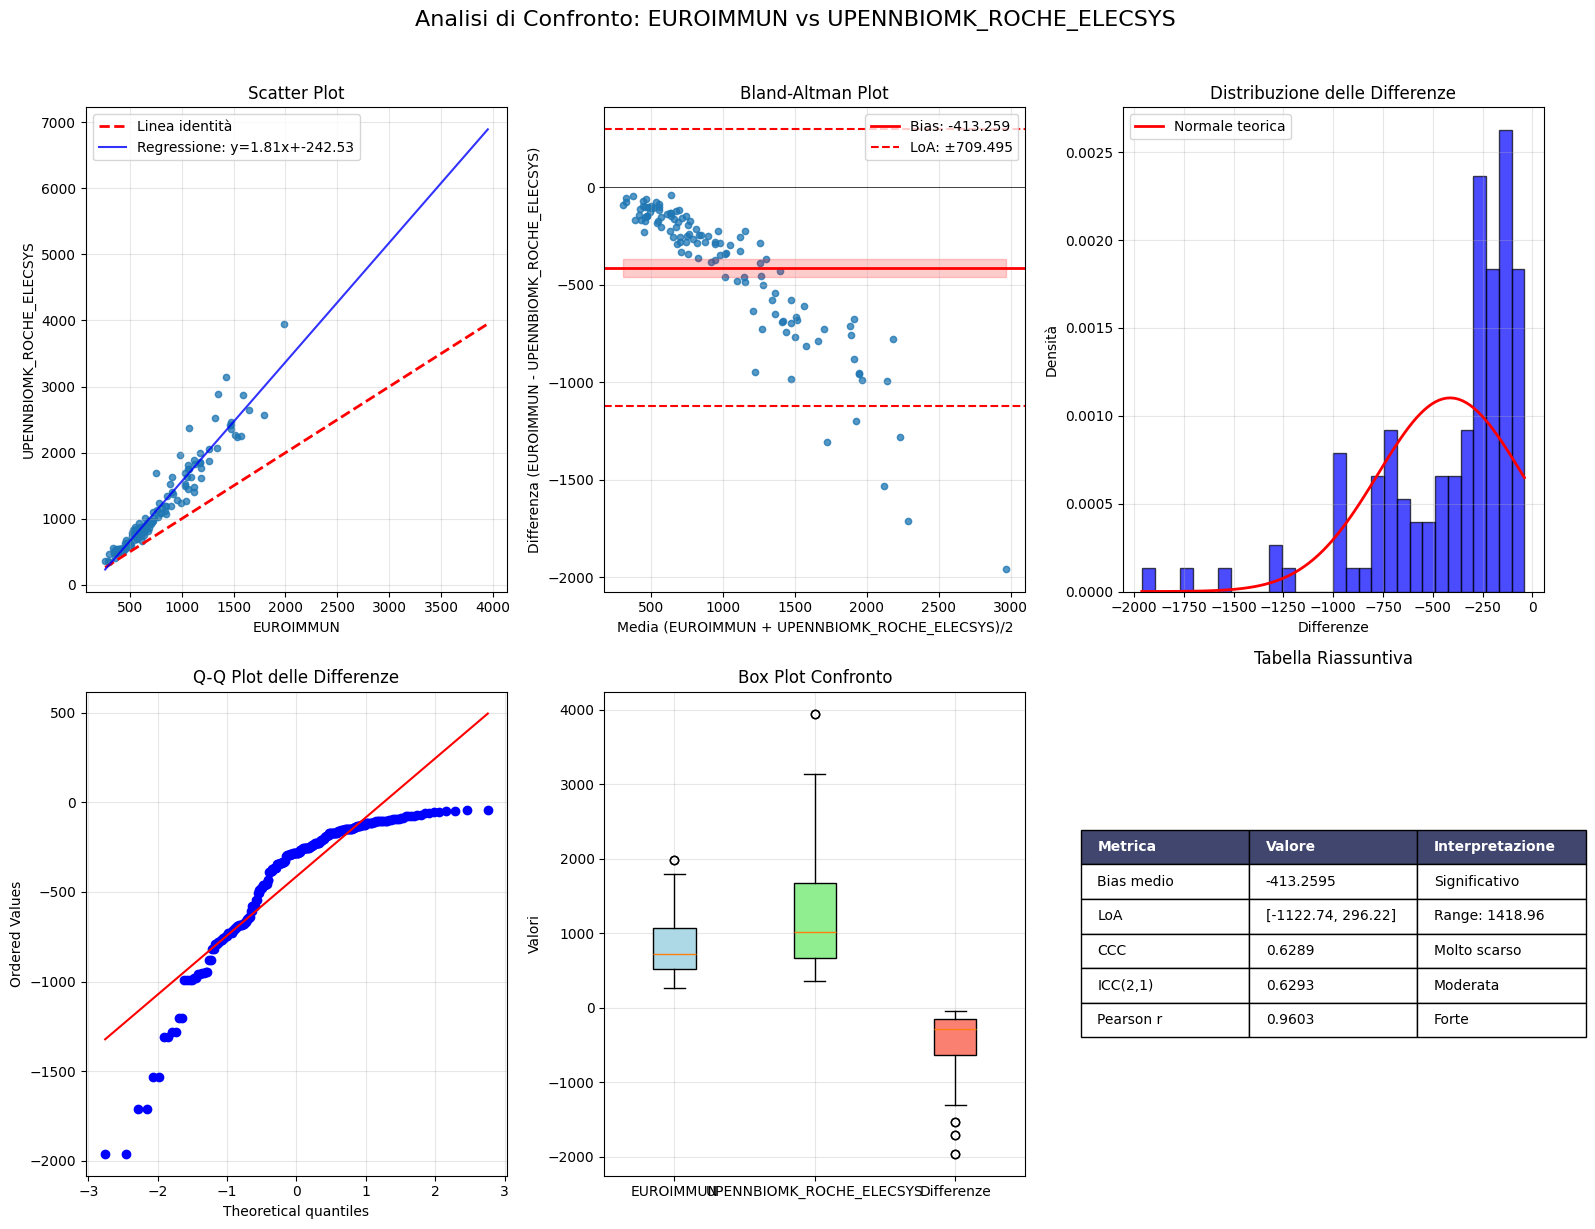


ACCESSO AI RISULTATI INDIVIDUALI

Puoi accedere a tutti i risultati dal dizionario 'results':
- results['t_test']: risultati del t-test
- results['wilcoxon']: risultati del test di Wilcoxon
- results['bland_altman']: risultati Bland-Altman
- results['ccc']: Concordance Correlation Coefficient
- results['icc']: Intraclass Correlation Coefficient
- results['intercambiabili']: True/False se i metodi sono intercambiabili


In [33]:
# Genera dati di esempio (sostituisci con i tuoi dati reali)

# Esegui l'analisi completa
results = comprehensive_method_comparison(
    x=x,
    y=y,
    method1_name=file_code_A,
    method2_name=file_code_B,
    alpha=0.05,
    create_plots=True
)

# Puoi accedere ai risultati individuali
print("\n" + "="*80)
print("ACCESSO AI RISULTATI INDIVIDUALI")
print("="*80)
print(f"\nPuoi accedere a tutti i risultati dal dizionario 'results':")
print(f"- results['t_test']: risultati del t-test")
print(f"- results['wilcoxon']: risultati del test di Wilcoxon")
print(f"- results['bland_altman']: risultati Bland-Altman")
print(f"- results['ccc']: Concordance Correlation Coefficient")
print(f"- results['icc']: Intraclass Correlation Coefficient")
print(f"- results['intercambiabili']: True/False se i metodi sono intercambiabili")

## Valutazion corrispondenza di un parametro misurato in maniera differente
### Analisi consigliate (ordine pratico)

#### A. Scatter + linea identità

* Traccia y (metodo 2) vs x (metodo 1) con la linea y=x.

* Se i punti stanno sulla y=x → buon accordo visivo.

#### B. Regressione per metodi di misura

* Deming (errore in entrambi): stima slope e intercept con IC95%.

    * Intercambiabilità buona se slope ≈ 1 e intercept ≈ 0 (e IC95% includono 1 e 0).

* Passing–Bablok: robusta e non-parametrica, ottima alternativa.

#### C. Bland–Altman (accordo a livello individuale)

* Calcola differenze (metodo2 − metodo1) vs medie ((m2+m1)/2).

* Stima bias (media delle differenze) e Limiti di Accordo:

    * LoA = bias ± 1.96·SD(differenze).

* Valuta se LoA rientrano nei limiti clinicamente accettabili (es. TEa o specifiche biologiche).

* Se la banda si allarga ai valori alti → eteroscedasticità → considera log-trasformare prima dell’analisi o usare LoA percentuali.

#### D. Coefficiente di Concordanza (CCC, Lin)

* Combina precisione e accuratezza. CCC ~1 suggerisce buona intercambiabilità.

### Regole pratiche di interpretazione

* r alto + Bland–Altman stretto + slope≈1 + intercetta≈0 → metodi comparabili.

* r alto ma bias evidente (intercetta ≠ 0) → correggibile con offset; intercambiabilità “as is” scarsa.

* r alto ma slope ≠ 1 → bias proporzionale; valuta correzione di calibrazione o non intercambiabilità.

* LoA troppo larghi anche se bias ≈ 0 → scarsa precisione; metodi non intercambiabili per uso clinico.

* Eteroscedasticità → valuta analisi su scala log e LoA percentuali.

In [ ]:
var_A = 'TauAB42_RAW'
var_B = 'TTAU_AB42'

In [ ]:
df_corr= df_focus[[var_A, var_B]]
print(len(df_corr), '  righe prima')
# Rimuovi le righe dove almeno uno dei due valori è nan
df_corr = df_corr.dropna()
print(len(df_corr), '  righe dopo')
x = df_corr[var_A]
y = df_corr[var_B]

1238   righe prima
1200   righe dopo


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, norm

pritn('### ANALISI DESCRITTIVA ###')
print(df_corr.describe())

diff = y - x
print("\n### STATISTICHE DESCRITTIVE DELLE DIFFERENZE ###")
print(f"Media: {np.mean(diff):.4f}")
print(f"Mediana: {np.median(diff):.4f}")
print(f"Deviazione standard: {np.std(diff, ddof=1):.4f}")
print(f"Asimmetria (skewness): {stats.skew(diff):.4f}")
print(f"Curtosi: {stats.kurtosis(diff):.4f}")
print(f"Min: {np.min(diff):.4f}")
print(f"Max: {np.max(diff):.4f}")

pritn("\n### NORMALITA' delle differenze ###")
shapiro_stat, shapiro_p = stats.shapiro(differenze)
print(f"Test di Shapiro-Wilk:")
print(f"  Statistica: {shapiro_stat:.6f}")
print(f"  P-value: {shapiro_p:.6f}")
print(f"  Risultato: {'Normale' if shapiro_p > 0.05 else 'NON normale'} (α=0.05)")


# Considerazione sulla dimensione del campione
print(f"\nCon n={len(differenze)} osservazioni:")
if len(differenze) > 1000:
    print("- Il Teorema del Limite Centrale rende i test parametrici robusti")
    print("- Anche piccole deviazioni dalla normalità risulteranno significative")
    print("- Guarda soprattutto i grafici (Q-Q plot) per valutazione pratica")


Pearson r=0.878, p=0
Deming: intercept=0.021, slope=0.605  (ideale: 0 e 1)
Bland–Altman: bias=-0.227, LoA= [-0.740, 0.285]
Bland–Altman %: bias=-44.16%, LoA= [-104.39%, 16.07%]
CCC=0.692


### Visualizzazione per valutare normalità

In [ ]:
# =====================================
# 3. VISUALIZZAZIONE GRAFICA
# =====================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Istogramma con curva normale
ax1 = axes[0, 0]
n, bins, patches = ax1.hist(differenze, bins=30, density=True, 
                            alpha=0.7, color='blue', edgecolor='black')
mu, sigma = np.mean(differenze), np.std(differenze, ddof=1)
x = np.linspace(differenze.min(), differenze.max(), 100)
ax1.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, 
         label='Normale teorica')
ax1.set_title('Istogramma delle differenze')
ax1.set_xlabel('Differenza')
ax1.set_ylabel('Densità')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Q-Q plot
ax2 = axes[0, 1]
stats.probplot(differenze, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot')
ax2.grid(True, alpha=0.3)

# Box plot
ax3 = axes[0, 2]
box = ax3.boxplot(differenze, vert=True, patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
ax3.set_title('Box Plot')
ax3.set_ylabel('Differenza')
ax3.grid(True, alpha=0.3)

# Density plot (KDE)
ax4 = axes[1, 0]
sns.kdeplot(data=differenze, ax=ax4, fill=True, color='blue', alpha=0.5)
ax4.axvline(np.mean(differenze), color='red', linestyle='--', 
            label=f'Media: {np.mean(differenze):.2f}')
ax4.axvline(np.median(differenze), color='green', linestyle='--', 
            label=f'Mediana: {np.median(differenze):.2f}')
ax4.set_title('Density Plot (KDE)')
ax4.set_xlabel('Differenza')
ax4.legend()
ax4.grid(True, alpha=0.3)

# P-P plot
ax5 = axes[1, 1]
probplot = stats.probplot(differenze, dist="norm")
theoretical_percentiles = probplot[0][0]
sample_percentiles = probplot[0][1]
actual_percentiles = stats.norm.cdf(sample_percentiles, mu, sigma)
theoretical_norm_percentiles = stats.norm.cdf(theoretical_percentiles)
ax5.scatter(theoretical_norm_percentiles, actual_percentiles, alpha=0.5)
ax5.plot([0, 1], [0, 1], 'r--', linewidth=2)
ax5.set_title('P-P Plot')
ax5.set_xlabel('Percentili teorici')
ax5.set_ylabel('Percentili empirici')
ax5.grid(True, alpha=0.3)

# ECDF vs Normal CDF
ax6 = axes[1, 2]
# ECDF empirica
x_sorted = np.sort(differenze)
y_ecdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
ax6.step(x_sorted, y_ecdf, where='post', label='ECDF empirica', color='blue')
# CDF normale teorica
x_theory = np.linspace(differenze.min(), differenze.max(), 100)
y_theory = stats.norm.cdf(x_theory, mu, sigma)
ax6.plot(x_theory, y_theory, 'r-', linewidth=2, label='CDF normale')
ax6.set_title('ECDF vs CDF Normale')
ax6.set_xlabel('Differenza')
ax6.set_ylabel('Probabilità cumulata')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle('Analisi di Normalità delle Differenze', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### paired T-test o paired wilkokson in base al risultato delle analisi precedenti

In [ ]:
# T-test
t_stat, p_value = stats.ttest_rel(x, y)

mean_diff = np.mean(y-x)
std_diff = np.std(y-x, ddof=1)

# Intervallo di confidenza al 95%
alpha = 0.05
ci_low = mean_diff - t.ppf(1-alpha/2, n-1) * se_diff
ci_high = mean_diff + t.ppf(1-alpha/2, n-1) * se_diff

# Effect size (Cohen's d)
cohens_d = mean_diff / std_diff

results = {
    'test': 'Paired t-test',
    'mean_diff': mean_diff,
    'std_diff': std_diff,
    't_statistic': t_stat,
    'p_value': p_value,
    'ci_95': (ci_low, ci_high),
    'cohens_d': cohens_d,
    'n': n,
    'significant': p_value < alpha
}

In [ ]:
# Test di Wilcoxon
statistic, p_value = stats.wilcoxon(x, y, alternative='two-sided')

# Calcola pseudo-mediana (Hodges-Lehmann estimator)
differences = x - y
walsh_averages = []
for i in range(len(differences)):
    for j in range(i, len(differences)):
        walsh_averages.append((differences[i] + differences[j]) / 2)
pseudo_median = np.median(walsh_averages)

# Effect size per Wilcoxon (r = Z / sqrt(N))
n = len(differences)
z_score = stats.norm.ppf(1 - p_value/2)  # Approssimazione
effect_size_r = z_score / np.sqrt(n)

results = {
    'test': 'Wilcoxon signed-rank test',
    'statistic': statistic,
    'p_value': p_value,
    'pseudo_median': pseudo_median,
    'median_diff': np.median(differences),
    'effect_size_r': effect_size_r,
    'n': n,
    'significant': p_value < alpha
}

In [ ]:
# Calcola medie e differenze
mean_values = (x + y) / 2
differences = x - y

# Statistiche
mean_diff = np.mean(differences)
std_diff = np.std(differences, ddof=1)
n = len(differences)

# Limiti di accordo (LoA)
z_score = stats.norm.ppf(1 - (1 - confidence) / 2)
loa_lower = mean_diff - z_score * std_diff
loa_upper = mean_diff + z_score * std_diff

# Intervalli di confidenza per bias e LoA
se_mean = std_diff / np.sqrt(n)
se_loa = np.sqrt(3 * std_diff**2 / n)

ci_mean = (mean_diff - z_score * se_mean, 
            mean_diff + z_score * se_mean)
ci_lower = (loa_lower - z_score * se_loa,
            loa_lower + z_score * se_loa)
ci_upper = (loa_upper - z_score * se_loa,
            loa_upper + z_score * se_loa)

# Test per bias sistematico (t-test su media delle differenze)
t_stat = mean_diff / se_mean
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n-1))

# Coefficiente di ripetibilità
repeatability_coeff = 1.96 * std_diff

# Percentage error
mean_all = np.mean(np.concatenate([x, y]))
percentage_error = (std_diff / mean_all) * 100 if mean_all != 0 else np.nan

results = {
    'test': 'Bland-Altman Analysis',
    'mean_diff': mean_diff,
    'std_diff': std_diff,
    'loa_lower': loa_lower,
    'loa_upper': loa_upper,
    'ci_mean': ci_mean,
    'ci_loa_lower': ci_lower,
    'ci_loa_upper': ci_upper,
    'bias_test_p': p_value,
    'repeatability_coeff': repeatability_coeff,
    'percentage_error': percentage_error,
    'n': n
}

In [ ]:
 """
Calcola il Concordance Correlation Coefficient (CCC) di Lin
"""
# Medie
mean_x = np.mean(x)
mean_y = np.mean(y)

# Varianze
var_x = np.var(x, ddof=1)
var_y = np.var(y, ddof=1)

# Deviazioni standard
std_x = np.sqrt(var_x)
std_y = np.sqrt(var_y)

# Covarianza
covariance = np.cov(x, y)[0, 1]

# Correlazione di Pearson
pearson_r = covariance / (std_x * std_y)

# CCC
ccc = (2 * covariance) / (var_x + var_y + (mean_x - mean_y)**2)

# Componenti del CCC
# Precision (correlazione di Pearson)
precision = pearson_r

# Accuracy (Cb - bias correction factor)
accuracy = ccc / pearson_r if pearson_r != 0 else 0

# Bootstrap per intervallo di confidenza
n_bootstrap = 1000
ccc_bootstrap = []
n = len(x)

for _ in range(n_bootstrap):
    indices = np.random.choice(n, n, replace=True)
    x_boot = x[indices]
    y_boot = y[indices]
    
    mean_x_boot = np.mean(x_boot)
    mean_y_boot = np.mean(y_boot)
    var_x_boot = np.var(x_boot, ddof=1)
    var_y_boot = np.var(y_boot, ddof=1)
    cov_boot = np.cov(x_boot, y_boot)[0, 1]
    
    ccc_boot = (2 * cov_boot) / (var_x_boot + var_y_boot + 
                                    (mean_x_boot - mean_y_boot)**2)
    ccc_bootstrap.append(ccc_boot)

ci_lower = np.percentile(ccc_bootstrap, 2.5)
ci_upper = np.percentile(ccc_bootstrap, 97.5)

# Interpretazione
if ccc > 0.99:
    strength = "Quasi perfetto"
elif ccc > 0.95:
    strength = "Sostanziale"
elif ccc > 0.90:
    strength = "Moderato"
elif ccc > 0.80:
    strength = "Scarso"
else:
    strength = "Molto scarso"

results = {
    'test': 'Concordance Correlation Coefficient',
    'ccc': ccc,
    'pearson_r': pearson_r,
    'precision': precision,
    'accuracy': accuracy,
    'ci_95': (ci_lower, ci_upper),
    'interpretation': strength,
    'n': n
}


In [ ]:

# --- Pearson ---
pritn('### Test di Pearson R ###')
r, p = pearsonr(x, y)
print(f"Pearson r={r:.3f}, p={p:.3g}")

# --- Deming regression (λ=1: var_errore_x ≈ var_errore_y; adatta se non sai altro) ---
def deming(x, y, lam=1.0):
    x = np.asarray(x); y = np.asarray(y)
    xbar, ybar = x.mean(), y.mean()
    Sxx = np.var(x, ddof=1)
    Syy = np.var(y, ddof=1)
    Sxy = np.cov(x, y, ddof=1)[0,1]
    # slope:
    B = (Syy - lam*Sxx + np.sqrt((Syy - lam*Sxx)**2 + 4*lam*Sxy**2)) / (2*Sxy)
    A = ybar - B*xbar
    return A, B

a, b = deming(x, y, lam=1.0)
print(f"Deming: intercept={a:.3f}, slope={b:.3f}  (ideale: 0 e 1)")

# --- Bland–Altman ---
diff = y - x
mean = (y + x) / 2
bias = diff.mean()
sd = diff.std(ddof=1)
loa_low, loa_high = bias - 1.96*sd, bias + 1.96*sd
print(f"Bland–Altman: bias={bias:.3f}, LoA= [{loa_low:.3f}, {loa_high:.3f}]")

# Se eteroscedasticità, usa percentuali:
pdiff = 100*(y - x)/mean
pbias = pdiff.mean()
psd = pdiff.std(ddof=1)
plow, phigh = pbias - 1.96*psd, pbias + 1.96*psd
print(f"Bland–Altman %: bias={pbias:.2f}%, LoA= [{plow:.2f}%, {phigh:.2f}%]")

# --- Concordance Correlation Coefficient (Lin) ---
def ccc(x, y):
    mx, my = x.mean(), y.mean()
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    sxy = np.cov(x, y, ddof=1)[0,1]
    r = sxy / np.sqrt(vx*vy)
    return (2*r*np.sqrt(vx*vy)) / (vx + vy + (mx - my)**2)

print(f"CCC={ccc(x,y):.3f}")


### Plot utili 

1) raffigurazione lineare, se punti si posizionano sulla retta a 45 gradi allora bene

2) Bland-Altman plot

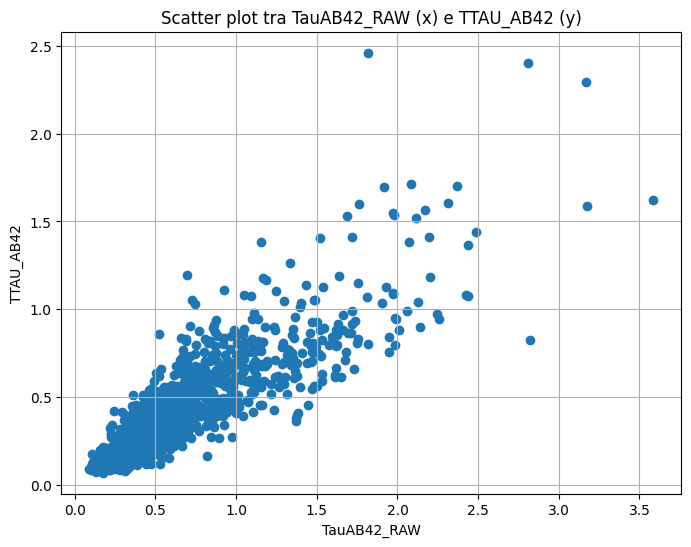

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color='red', linestyle='--', label='y = x')
plt.xlabel("TauAB42_RAW")
plt.ylabel("TTAU_AB42")
plt.title("Scatter plot tra TauAB42_RAW (x) e TTAU_AB42 (y)")
plt.legend()
plt.grid(True)
plt.show()


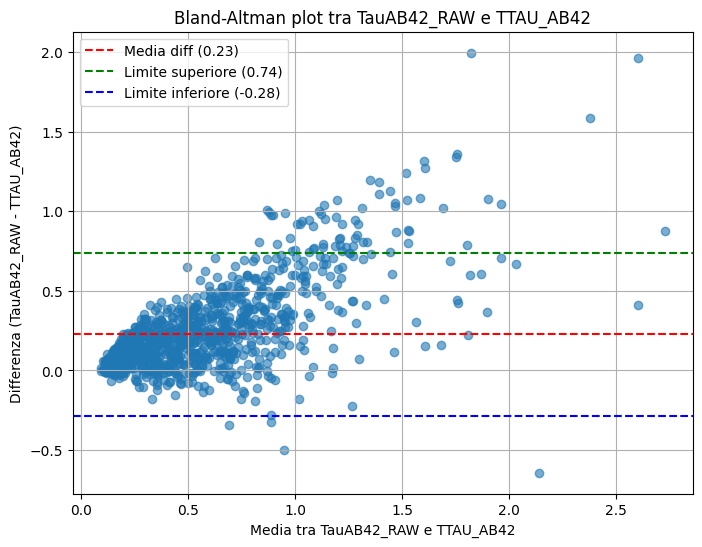

In [ ]:
import numpy as np

# Calcola le medie e le differenze tra le due variabili
means = (x + y) / 2
diffs = x - y

mean_diff = np.mean(diffs)
std_diff = np.std(diffs, ddof=1)  # ddof=1 per std campionaria

upper_limit = mean_diff + 1.96 * std_diff
lower_limit = mean_diff - 1.96 * std_diff

plt.figure(figsize=(8,6))
plt.scatter(means, diffs, alpha=0.6)
plt.axhline(mean_diff, color='red', linestyle='--', label=f'Media diff ({mean_diff:.2f})')
plt.axhline(upper_limit, color='green', linestyle='--', label=f'Limite superiore ({upper_limit:.2f})')
plt.axhline(lower_limit, color='blue', linestyle='--', label=f'Limite inferiore ({lower_limit:.2f})')
plt.xlabel("Media tra TauAB42_RAW e TTAU_AB42")
plt.ylabel("Differenza (TauAB42_RAW - TTAU_AB42)")
plt.title("Bland-Altman plot tra TauAB42_RAW e TTAU_AB42")
plt.legend()
plt.grid(True)
plt.show()


__Analisi di Bland-Altman__\
Questo è l'approccio gold standard per valutare l'accordo tra metodi:

*Come funziona*:

Crea un grafico con la media delle due misurazioni sull'asse X\
Mette la differenza tra le misurazioni sull'asse Y\
Calcola i limiti di accordo (media ± 1.96 × deviazione standard delle differenze)


*Interpretazione*:

Valuta se c'è un bias sistematico (differenza media diversa da zero)\
Verifica se il bias cambia al variare dei valori (eteroschedasticità)\
I limiti di accordo ti dicono entro quali valori si trova il 95% delle differenze